In [2]:

!pip install goatools


  Obtaining dependency information for goatools from https://files.pythonhosted.org/packages/98/6d/8c3a3f2b77c17ef37e96d69ee49ef62c18d72d2c6e507fa5046d6f47082e/goatools-1.3.11-py3-none-any.whl.metadata
  Obtaining dependency information for xlsxwriter from https://files.pythonhosted.org/packages/a7/ea/53d1fe468e63e092cf16e2c18d16f50c29851242f9dd12d6a66e0d7f0d02/XlsxWriter-3.2.0-py3-none-any.whl.metadata
  Preparing metadata (setup.py) ... done
  Obtaining dependency information for pydot from https://files.pythonhosted.org/packages/7f/90/c9b51f3cdff89cd8f93382060330f43d1af098a6624cff439e700791e922/pydot-2.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for rich from https://files.pythonhosted.org/packages/87/67/a37f6214d0e9fe57f6ae54b2956d550ca8365857f42a1ce0392bb21d9410/rich-13.7.1-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 6.7 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.7/240.7 kB 16.8 MB/s eta 0

In [1]:
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

In [2]:
from goatools.base import download_go_basic_obo
from goatools.base import download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader

obo_fname = download_go_basic_obo()
fin_gene2go = download_ncbi_associations()
obodag = GODag("go-basic.obo")

  EXISTS: go-basic.obo
  EXISTS: gene2go
go-basic.obo: fmt(1.2) rel(2024-01-17) 45,869 Terms


In [3]:
# Read NCBI's gene2go. Store annotations in a list of namedtuples

objanno = Gene2GoReader(fin_gene2go, taxids=[9606])
ns2assoc = objanno.get_ns2assc()

for nspc, id2gos in ns2assoc.items():
    print("{NS} {N:,} annotated human genes".format(NS=nspc, N=len(id2gos)))
    
    
    

HMS:0:00:38.648693 346,071 annotations, 20,759 genes, 18,733 GOs, 1 taxids READ: gene2go 
MF 18,352 annotated human genes
CC 19,785 annotated human genes
BP 18,693 annotated human genes


In [4]:
import os

current_directory = os.getcwd()
print("Current directory:", current_directory)


Current directory: /Users/ruhangandhi/Documents/Year 3 work/Dissertation work/Dissertation project code 1:2


In [5]:
!mv /Users/ruhangandhi/Documents/gene_result.txt ./

!python /Users/ruhangandhi/anaconda3/bin/ncbi_gene_results_to_python.py gene_result.txt -o genes_ncbi_human_proteincoding.py

mv: /Users/ruhangandhi/Documents/gene_result.txt: No such file or directory
      20,626 lines READ:  gene_result.txt
      20,607 geneids WROTE: genes_ncbi_human_proteincoding.py


In [6]:
from genes_ncbi_human_proteincoding import GENEID2NT as GeneID2nt_human

print(len(GeneID2nt_human))

20607


In [7]:
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_human.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction method


Load BP Ontology Enrichment Analysis ...
 83% 17,024 of 20,607 population items found in association

Load CC Ontology Enrichment Analysis ...
 88% 18,139 of 20,607 population items found in association

Load MF Ontology Enrichment Analysis ...
 85% 17,598 of 20,607 population items found in association


In [8]:
id_mapper = {}

for key in GeneID2nt_human:
    id_mapper[GeneID2nt_human[key].Symbol] = GeneID2nt_human[key].GeneID
    
rev_mapper = {v: k for k, v in id_mapper.items()}  

In [9]:
#run one time to initialize

# Read NCBI's gene2go. Store annotations in a list of namedtuples
objanno = Gene2GoReader(fin_gene2go, taxids=[9606])
# Get namespace2association where:
#    namespace is:
#        BP: biological_process               
#        MF: molecular_function
#        CC: cellular_component
#    assocation is a dict:
#        key: NCBI GeneID
#        value: A set of GO IDs associated with that gene
ns2assoc = objanno.get_ns2assc()

HMS:0:00:39.090988 346,071 annotations, 20,759 genes, 18,733 GOs, 1 taxids READ: gene2go 


In [40]:
#run one time to initialize
goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_human.keys(), # List of mouse protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction method


Load BP Ontology Enrichment Analysis ...
 83% 17,024 of 20,607 population items found in association

Load CC Ontology Enrichment Analysis ...
 88% 18,139 of 20,607 population items found in association

Load MF Ontology Enrichment Analysis ...
 85% 17,598 of 20,607 population items found in association


In [10]:
import numpy as np

def go_analysis(gene_list):
    
    mapped_gene = []

    for gene in gene_list:
        try:
            mapped_gene.append(id_mapper[gene])
        except:
            pass 
    
    goea_results_all = goeaobj.run_study(mapped_gene)  
    
    goea_results_sig = [r for r in goea_results_all if r.p_fdr_bh<0.05]
    
    
    df_go = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

    df_go = df_go[df_go.n_genes > 1]
    df_go['LogP'] = -np.log10(df_go['p'])
    return df_go

In [11]:
#==================================================
#actual go analysis: 

import pandas as pd


data = pd.read_table("og_symbols.txt", header=None, encoding='utf-8')

# Strip non-breaking spaces and regular spaces from the data
data[0] = data[0].apply(lambda x: x.replace('\xa0', '').strip())

# Convert the column to a list
words_list = data[0].tolist()

# Print to verify
print(words_list)




['SYNCRIP', 'TOP1', 'PTBP1', 'RAVER1', 'IGF2BP2', 'RBMX', 'DDX3X', 'PCBP1', 'MCM5', 'DDX17', 'MATR3', 'DHX9', 'ERG', 'FUBP3', 'SFPQ', 'TRMT6', 'HNRNPA3', 'HNRNPH1', 'HNRNPL', 'HNRNPD', 'YBX1', 'CNBP', 'RALY', 'FAM120A', 'HNRNPAB', 'HNRNPM', 'HNRNPK', 'SLC25A4', 'HNRNPA0', 'PABPN1', 'TRMT61A', 'RFC1', 'SLC19A1', 'PCBP2', 'HNRNPA2B1', 'ITGA4', 'HNRNPDL', 'FUS', 'FBXW11', 'EED', 'HIST1H2BA', 'IL7R', 'SUB1', 'NONO', 'STAU1', 'TARDBP', 'CIRBP', 'HNRNPUL2', 'HNRNPR', 'HNRNPA1', 'HNRNPUL1', 'DDX5', 'IGF2BP1', 'ZBP1', 'ILF2', 'ZNF326', 'C2', 'HNRNPC', 'SNRPC', 'FN1', 'HNRNPH3', 'HNRNPF', 'HNRNPH2', 'PUF60']


/Users/ruhangandhi/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [12]:
#run one time to initialize
GO_items = []

temp = goeaobj.ns2objgoea['BP'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['CC'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['MF'].assoc
for item in temp:
    GO_items += temp[item]

In [34]:
target_genes = ["HNRNPCL1", "DHX9", "IGF2BP2", "ANK2", "DCUN1D1", "RALY", "CUL1", "CAND1", "HNRNPA0", "SYNCRIP", "ILF2", "NEDD8", "HNRNPA2B1", "HNRNPA1", "PTBP1", "LARP1", "CUL2", "HNRNPF", "HNRNPA3", "HNRNPL", "DHX30", "CUL4B", "DDX5", "PCBP2", "HNRNPR", "PABPN1", "HNRNPDL", "HNRNPH1", "TRMT61A", "DDX17", "RFC1", "SLC19A1", "IGF2BP1", "ZBP1", "PUF60", "CUL4A", "TIA1", "RBM3", "HNRNPH3", "COPS5", "TRMT6", "FUS", "MATR3", "DDX3X", "SRSF3", "TIAL1", "CUL3", "HNRNPUL2", "PCBP1", "HNRNPK", "SNRPA", "DHX15", "KHSRP", "PABPC4", "EED", "HNRNPH2", "SREK1", "CUL5", "PABPC1", "RAVER1", "YBX1", "SSB", "IL7R", "EWSR1", "HNRNPAB", "CIRBP", "TFG", "RBMX", "HNRNPUL1", "U2AF2", "STAU1", "HNRNPD", "COPS6", "SLC25A4", "AGO1", "TARDBP", "TAF15", "SUB1"]
target_genes = [id_mapper[gene] for gene in target_genes if gene in id_mapper]

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_human.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.1, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction methodgoea_results_all = goeaobj.run_study()

goea_results_all = goeaobj.run_study(target_genes)

goea_results_sig = [r for r in goea_results_all if r.p_fdr_bh<0.01]
    
    
df_go = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])
# # 解析和解释结果
# for goea_result in goea_results_all:
#     go_term = goea_result.GO
#     go_name = goea_result[go_term].name
#     p_value = goea_result.p_uncorrected
#     if p_value < 0.05:
#         print(f"{go_term}\t{go_name}\t{p_value}")



Load BP Ontology Enrichment Analysis ...
 83% 17,024 of 20,607 population items found in association

Load CC Ontology Enrichment Analysis ...
 88% 18,139 of 20,607 population items found in association

Load MF Ontology Enrichment Analysis ...
 85% 17,598 of 20,607 population items found in association

Runing BP Ontology Analysis: current study set of 78 IDs.
 97%     76 of     78 study items found in association
100%     78 of     78 study items found in population(20607)
Calculating 12,180 uncorrected p-values using fisher_scipy_stats
  12,180 terms are associated with 17,024 of 20,607 population items
     458 terms are associated with     76 of     78 study items
  METHOD fdr_bh:
      36 GO terms found significant (< 0.1=alpha) ( 36 enriched +   0 purified): statsmodels fdr_bh
      59 study items associated with significant GO IDs (enriched)
       0 study items associated with significant GO IDs (purified)

Runing CC Ontology Analysis: current study set of 78 IDs.
100%     78

In [35]:
# Initialize an empty list
data_list = []

# Iterate over GO enrichment analysis results
for goea_result in goea_results_all:
    data_list.append({
        'GO': goea_result.GO,
        'Term': goea_result.goterm.name,
        'NS': goea_result.goterm.namespace,
        'Study_Count': goea_result.study_count,
        'Population_Count': goea_result.pop_count,
        'P-value': goea_result.p_uncorrected,
        'Corrected P-value': goea_result.p_fdr_bh,
        'Gene_ratio': goea_result.ratio_in_study,
    })

# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(data_list)
df


,GO,Term,NS,Study_Count,Population_Count,P-value,Corrected P-value,Gene_ratio
0,GO:0000398,"mRNA splicing, via spliceosome",biological_process,17,186,3.236680e-19,3.942277e-15,"(17, 78)"
1,GO:0006396,RNA processing,biological_process,12,68,2.195322e-17,1.336951e-13,"(12, 78)"
2,GO:0070934,CRD-mediated mRNA stabilization,biological_process,7,11,2.753935e-15,1.118097e-11,"(7, 78)"
3,GO:1900152,negative regulation of nuclear-transcribed mRN...,biological_process,6,9,2.011930e-13,5.568768e-10,"(6, 78)"
4,GO:0006397,mRNA processing,biological_process,13,186,2.286030e-13,5.568768e-10,"(13, 78)"
...,...,...,...,...,...,...,...,...
18578,GO:0034713,type I transforming growth factor beta recepto...,molecular_function,0,11,1.000000e+00,1.000000e+00,"(0, 78)"
18579,GO:0004104,cholinesterase activity,molecular_function,0,3,1.000000e+00,1.000000e+00,"(0, 78)"
18580,GO:0031716,calcitonin receptor binding,molecular_function,0,2,1.000000e+00,1.000000e+00,"(0, 78)"
18581,GO:0004415,hyalurononglucosaminidase activity,molecular_function,0,7,1.000000e+00,1.000000e+00,"(0, 78)"


In [36]:
df.loc[:,['Term','NS','P-value','Study_Count']]

,Term,NS,P-value,Study_Count
0,"mRNA splicing, via spliceosome",biological_process,3.236680e-19,17
1,RNA processing,biological_process,2.195322e-17,12
2,CRD-mediated mRNA stabilization,biological_process,2.753935e-15,7
3,negative regulation of nuclear-transcribed mRN...,biological_process,2.011930e-13,6
4,mRNA processing,biological_process,2.286030e-13,13
...,...,...,...,...
18578,type I transforming growth factor beta recepto...,molecular_function,1.000000e+00,0
18579,cholinesterase activity,molecular_function,1.000000e+00,0
18580,calcitonin receptor binding,molecular_function,1.000000e+00,0
18581,hyalurononglucosaminidase activity,molecular_function,1.000000e+00,0


In [37]:
import pandas as pd

import pandas as pd

# Assuming 'df' is your DataFrame

# First, sort the DataFrame by 'P-value' in ascending order
df_sorted = df.sort_values(by='P-value', ascending=True)

# Then group by 'NS', and for each group, select the top 10 rows
# Ensure to select only the specified columns after extracting the top 10
top_10_per_ns = df_sorted.groupby('NS').apply(lambda x: x.nsmallest(10, 'P-value')[['Term', 'NS', 'P-value', 'Study_Count']]).reset_index(drop=True)

top_10_per_ns


/var/folders/t8/8jl881fs4xb8bty5c41g82pr0000gn/T/ipykernel_42107/3983392359.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_10_per_ns = df_sorted.groupby('NS').apply(lambda x: x.nsmallest(10, 'P-value')[['Term', 'NS', 'P-value', 'Study_Count']]).reset_index(drop=True)


,Term,NS,P-value,Study_Count
0,"mRNA splicing, via spliceosome",biological_process,3.236680e-19,17
1,RNA processing,biological_process,2.195322e-17,12
2,CRD-mediated mRNA stabilization,biological_process,2.753935e-15,7
3,negative regulation of nuclear-transcribed mRN...,biological_process,2.011930e-13,6
4,mRNA processing,biological_process,2.286030e-13,13
5,positive regulation of cytoplasmic translation,biological_process,1.177391e-11,6
6,"regulation of alternative mRNA splicing, via s...",biological_process,3.074768e-11,8
7,protein localization to cytoplasmic stress gra...,biological_process,3.785857e-11,5
8,RNA splicing,biological_process,8.762344e-11,11
9,regulation of RNA splicing,biological_process,2.871023e-10,8


In [38]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# Predefine the color map
color_map = ['blue', 'green', 'red']


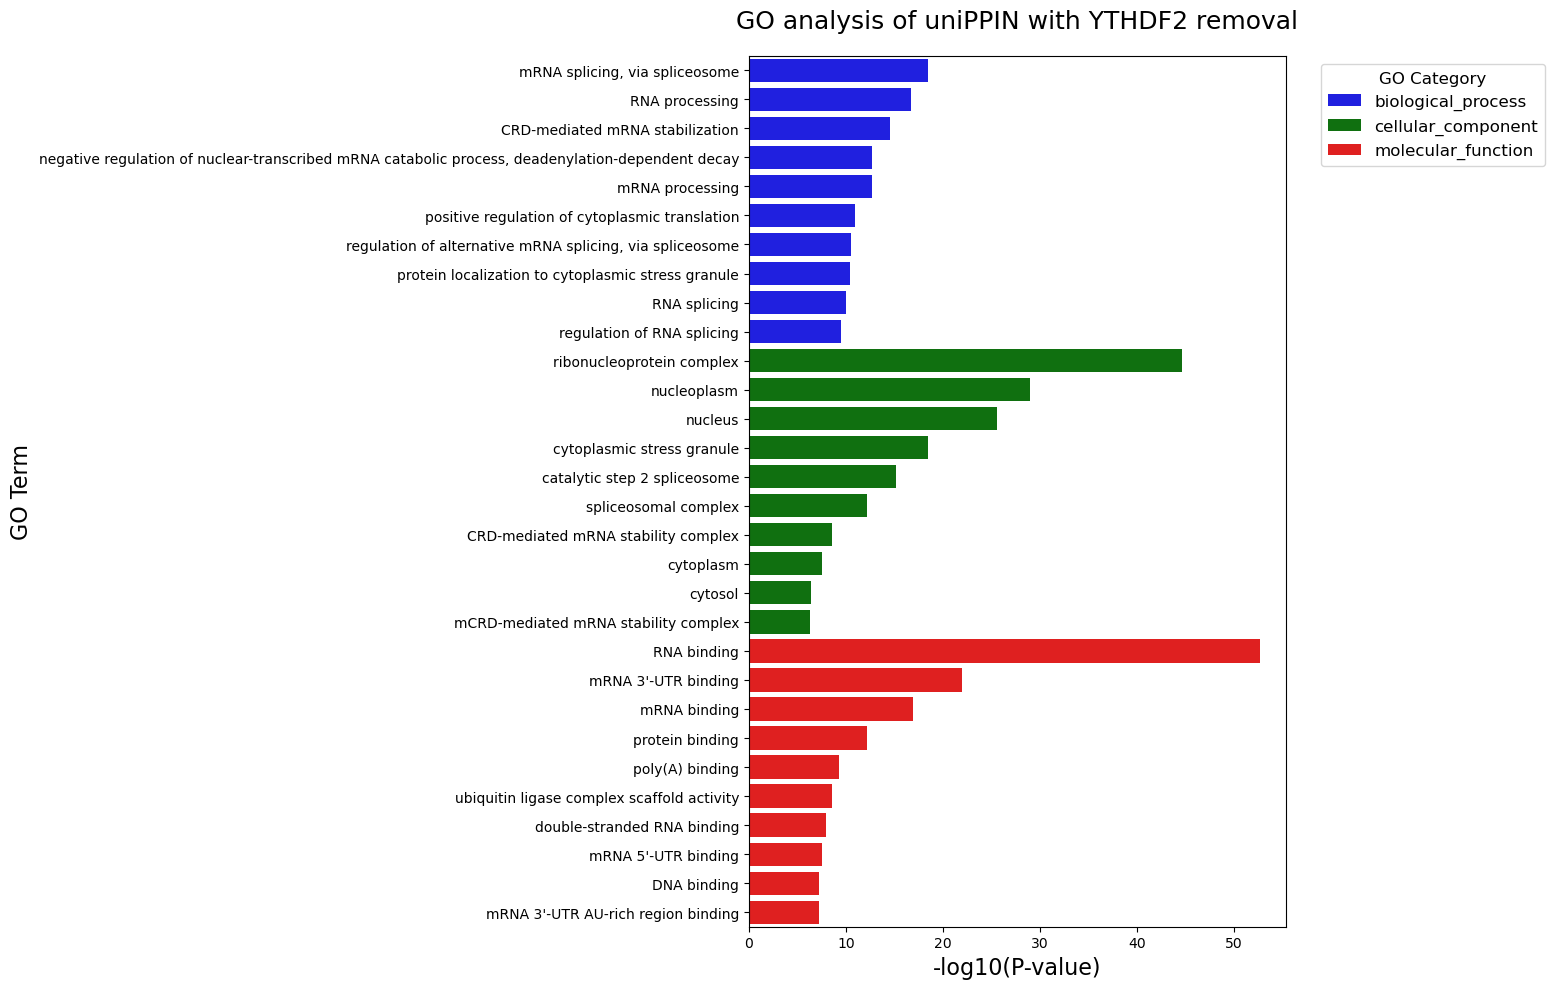

In [39]:
import numpy as np


# Calculate -log10(P-value) and add it as a new column to the DataFrame
top_10_per_ns['-log10(P-value)'] = -np.log10(top_10_per_ns['P-value'])

# Now, try plotting again with the corrected column name
plt.figure(figsize=(16, 10))
sns.barplot(x='-log10(P-value)', y='Term', hue='NS', data=top_10_per_ns, dodge=False, palette= color_map)

plt.xlabel('-log10(P-value)', fontsize=16)
plt.ylabel('GO Term', fontsize=16)
plt.title('GO analysis of uniPPIN with YTHDF2 removal', fontsize=18, pad=20)
plt.legend(title='GO Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='large', title_fontsize='large')

plt.tight_layout()
plt.savefig('original_unippin_GO_analysis.png', dpi=300)  # Save the enhanced plot

plt.show()


/var/folders/t8/8jl881fs4xb8bty5c41g82pr0000gn/T/ipykernel_42107/2667442910.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_5_per_ns = top_10_per_ns.groupby('NS').apply(lambda group: group.nsmallest(5, 'P-value')).reset_index(drop=True)


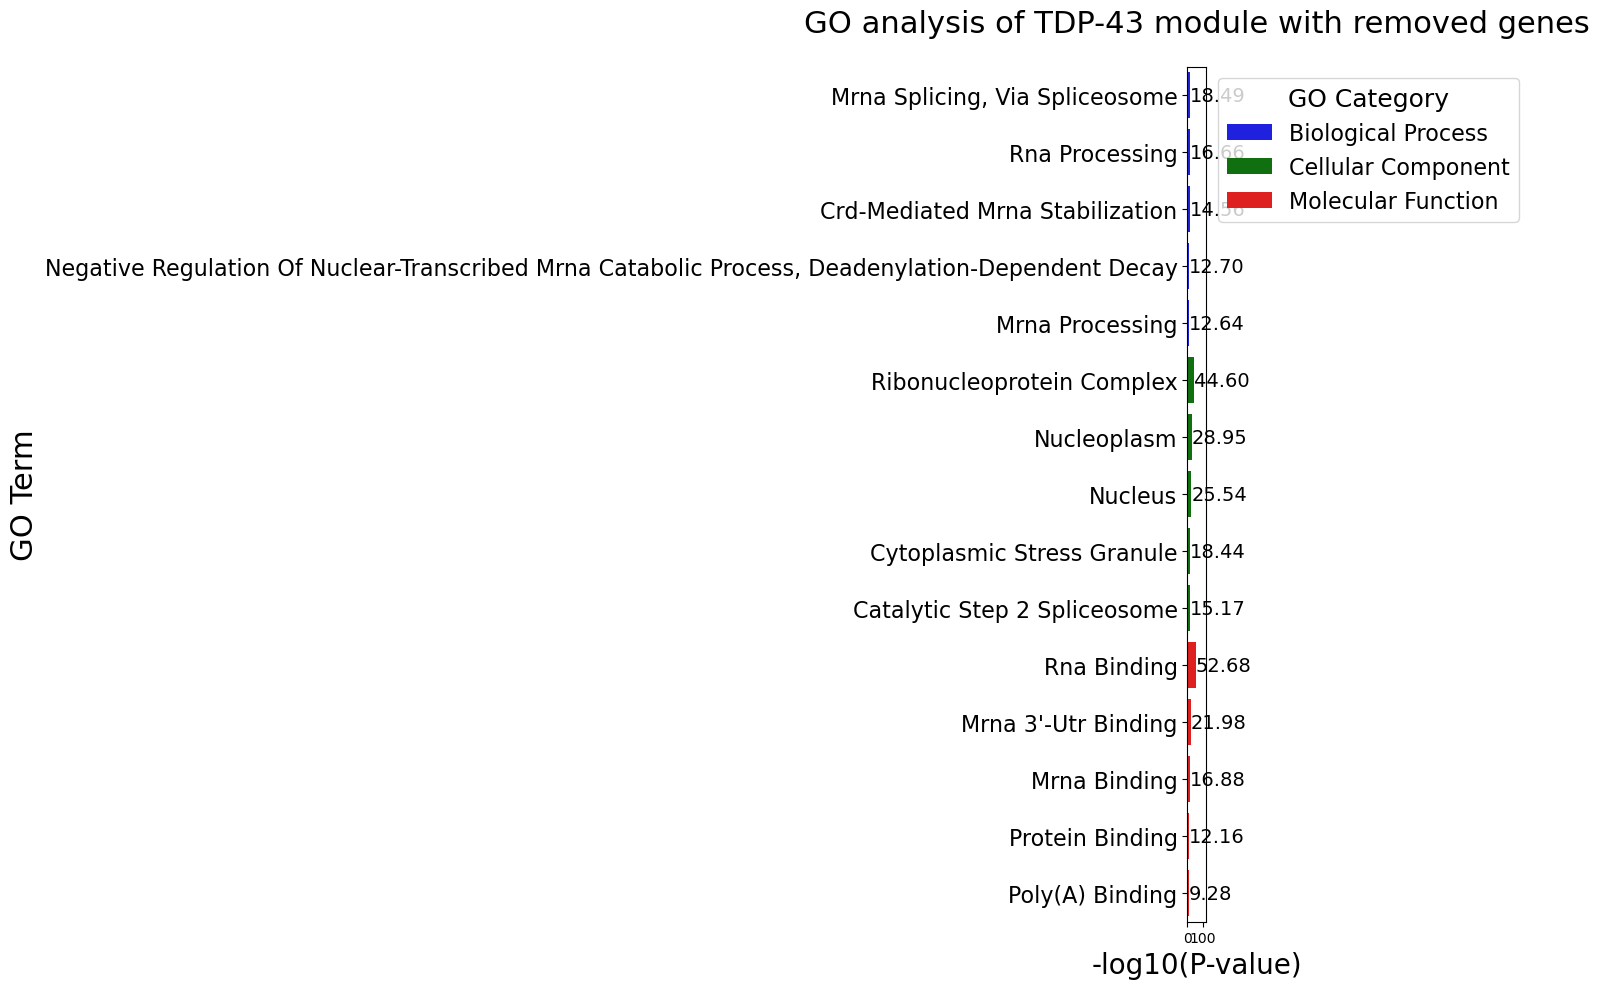

In [42]:
# Step 1: Filter the top 5 terms for each category
top_5_per_ns = top_10_per_ns.groupby('NS').apply(lambda group: group.nsmallest(5, 'P-value')).reset_index(drop=True)

# Step 2: Capitalize the first letter of each term
top_5_per_ns['Term'] = top_5_per_ns['Term'].str.title()

# Step 3: Calculate -log10(P-value) for plotting
top_5_per_ns['-log10(P-value)'] = -np.log10(top_5_per_ns['P-value'])

# Step 4: Define the mapping for categories to capitalized names with spaces
category_map = {
    'biological_process': 'Biological Process',
    'cellular_component': 'Cellular Component',
    'molecular_function': 'Molecular Function'
}

# Apply the category map to the 'NS' column
top_5_per_ns['NS'] = top_5_per_ns['NS'].map(category_map)

# Step 5: Plot the filtered data
plt.figure(figsize=(16, 10))

# Create barplot
ax = sns.barplot(x='-log10(P-value)', y='Term', hue='NS', data=top_5_per_ns, dodge=False, palette=color_map)

# Increase text size for labels
plt.xlabel('-log10(P-value)', fontsize=20)  # Larger x-axis label
plt.ylabel('GO Term', fontsize=22)          # Slightly larger y-axis label
plt.title('GO analysis of TDP-43 module with removed genes', fontsize=22, pad=25)  # Larger title

# Adjust legend with modified labels
plt.legend(title='GO Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16, title_fontsize=18)

# Add annotations to bars manually with shift to the right
for idx, row in top_5_per_ns.iterrows():
    x = row['-log10(P-value)']  # The -log10(P-value) for each bar
    y = idx  # The position of the bar (index for the row)
    
    # Shift the label to the right by adding an offset to `x`
    ax.text(x + 0.1, y, f'{x:.2f}', ha='left', va='center', fontsize=14)  # Slightly bigger p-value label size

# Increase font size of terms on y-axis
ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)  # Larger font size for GO terms on y-axis

# Extend x-axis to finish at 120
plt.xlim(0, 120)

plt.tight_layout()
plt.savefig('filtered_unippin_GO_analysis_with_labels_shifted_and_formatted_legend_extended_xaxis.png', dpi=300)  # Save the filtered plot

plt.show()


/var/folders/t8/8jl881fs4xb8bty5c41g82pr0000gn/T/ipykernel_42107/2098992688.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_5_per_ns = top_10_per_ns.groupby('NS').apply(lambda group: group.nsmallest(5, 'P-value')).reset_index(drop=True)


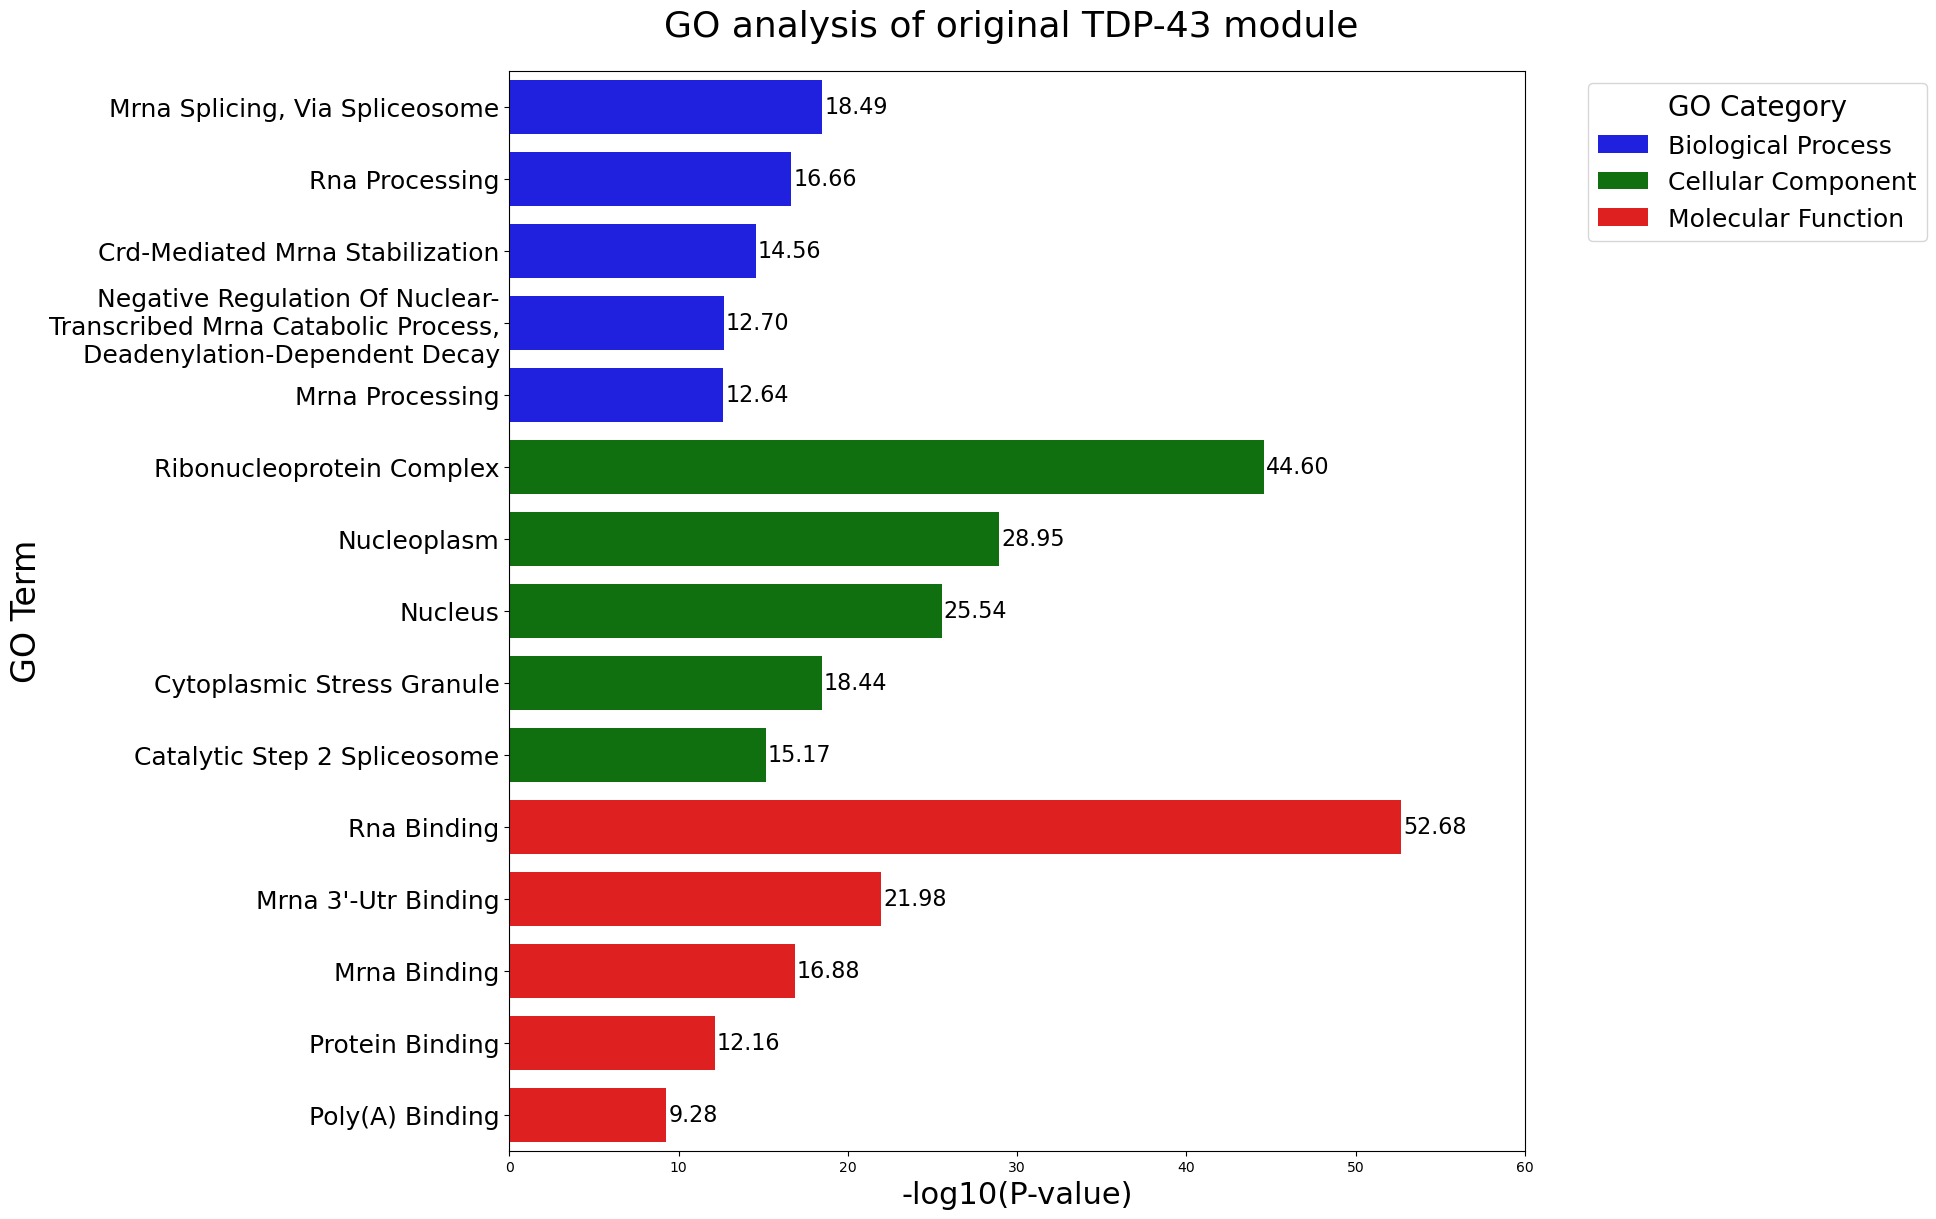

In [48]:
import textwrap

# Step 1: Filter the top 5 terms for each category
top_5_per_ns = top_10_per_ns.groupby('NS').apply(lambda group: group.nsmallest(5, 'P-value')).reset_index(drop=True)

# Step 2: Capitalize the first letter of each term
top_5_per_ns['Term'] = top_5_per_ns['Term'].str.title()

# Step 3: Calculate -log10(P-value) for plotting
top_5_per_ns['-log10(P-value)'] = -np.log10(top_5_per_ns['P-value'])

# Step 4: Define the mapping for categories to capitalized names with spaces
category_map = {
    'biological_process': 'Biological Process',
    'cellular_component': 'Cellular Component',
    'molecular_function': 'Molecular Function'
}

# Apply the category map to the 'NS' column
top_5_per_ns['NS'] = top_5_per_ns['NS'].map(category_map)

# Step 5: Predefine the color map
color_map = ['blue', 'green', 'red']

# Step 6: Wrap long terms in 'Term' column
max_len = 40  # Adjust this value if you want a larger or smaller line length
top_5_per_ns['Term'] = top_5_per_ns['Term'].apply(lambda x: "\n".join(textwrap.wrap(x, max_len)))

# Step 7: Plot the filtered data
plt.figure(figsize=(18, 12))  # Increased figure width for more space

# Create barplot with predefined color map and adjust bar width
ax = sns.barplot(x='-log10(P-value)', y='Term', hue='NS', data=top_5_per_ns, dodge=False, palette=color_map, width=0.75)  # Reduced width for more space between bars

# Increase text size for labels
plt.xlabel('-log10(P-value)', fontsize=22)  # Slightly larger x-axis label
plt.ylabel('GO Term', fontsize=24)          # Slightly larger y-axis label
plt.title('GO analysis of original TDP-43 module ', fontsize=26, pad=25)  # Larger title

# Adjust legend with modified labels
plt.legend(title='GO Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=18, title_fontsize=20)

# Add annotations to bars manually with shift to the right
for idx, row in top_5_per_ns.iterrows():
    x = row['-log10(P-value)']  # The -log10(P-value) for each bar
    y = idx  # The position of the bar (index for the row)
    
    # Shift the label to the right by adding an offset to `x`
    ax.text(x + 0.1, y, f'{x:.2f}', ha='left', va='center', fontsize=16)  # Larger annotation size

# Increase font size of terms on y-axis and rotate labels for better fitting
ax.set_yticklabels(ax.get_yticklabels(), fontsize=18)  # Larger font size for GO terms on y-axis
plt.yticks(rotation=0)  # Set rotation to 0 degrees, or try 90 degrees if still squishing

# Set x-axis range and ticks to increments of 10 up to 60
plt.xlim(0, 60)  # Adjusted x-limits
plt.xticks(np.arange(0, 61, 10))  # Set x-ticks to increment by 10

# Ensure proper layout and save the figure
plt.tight_layout()
plt.subplots_adjust(right=0.85, top=0.95, bottom=0.05)  # Adjust space for the legend and top/bottom padding

plt.savefig('filtered_unippin_GO_analysis_with_labels_shifted_and_formatted_legend_extended_xaxis_60_bigger_text.png', dpi=300)  # Save the plot

plt.show()
